### Introduction

This project explores the use of machine learning techniques to analyze and predict airfare purchasing opportunities using a custom flight pricing dataset collected over approximately one year. The dataset was generated using a Python-based scraping system that recorded 10–15 flight observations per day for primarily Houston-to-Japan routes, resulting in over 4,000 observations spanning from July 2025 to May 2026. Each observation includes information such as airline, departure time, number of stops, duration, total ticket cost, search timestamp, and days remaining until departure.

The primary goal of this project is not to directly predict exact ticket prices, but instead to model an “optimal booking strategy” classification problem. A target variable was engineered to classify whether a flight should be considered a BUY or WAIT opportunity based on how close the current ticket price was to the minimum future price observed within a rolling 14-day window. This reframes the problem into a practical decision-making task focused on identifying favorable booking opportunities.

Several machine learning models were evaluated throughout the project, including Logistic Regression, Random Forest, and XGBoost. Because the dataset contains strong temporal structure, chronological train/validation/test splitting was used instead of random splitting to better simulate real-world forecasting conditions. Additional precautions were taken to reduce temporal leakage by introducing purge gaps between splits when constructing rolling-window target variables.

The project also investigates broader machine learning challenges associated with time-dependent data, including feature engineering, probability threshold tuning, model calibration, temporal distribution shift, and generalization across different booking horizons. Particular attention is given to how airfare pricing behavior changes as departure dates approach, and how these changes impact model performance over time.

### Data Cleaning

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Helper functions for data preprocessing, model evaluation, and visualization
# Imported from helper.py
from helper import (create_target_variable,
    split_data_chronologically,
    inspect_splits,
    preprocess_data,
    evaluate_model,
    print_evaluation_metrics,
    plot_roc_curve
)

In [3]:
from IPython.display import display
df = pd.read_csv("Data/FlightData.csv")

display(df.head())
df.info()
display(df.describe())


,airline,flight_code,source_city,source_airport,departure_time,stops,duration,destination_city,destination_airport,arrival_time,class,itinerary_type,currency,total_cost,day_searched,timestamp_searched,departure_date,return_date
0,United Airlines,7937,Houston,IAH,morning,0,14.08,Tokyo,HND,afternoon,ECONOMY,ROUNDTRIP,USD,1872,Tuesday,2025/07/15,2026-01-06,2026-01-16
1,All Nippon Airways,113,Houston,IAH,morning,0,14.08,Tokyo,HND,afternoon,ECONOMY,ROUNDTRIP,USD,1877,Tuesday,2025/07/15,2026-01-06,2026-01-16
2,All Nippon Airways,113,Houston,IAH,morning,0,14.08,Tokyo,HND,afternoon,ECONOMY,ROUNDTRIP,USD,2080,Tuesday,2025/07/15,2026-01-06,2026-01-16
3,United Airlines,7937,Houston,IAH,morning,0,14.08,Tokyo,HND,afternoon,ECONOMY,ROUNDTRIP,USD,2080,Tuesday,2025/07/15,2026-01-06,2026-01-16
4,United Airlines,7937,Houston,IAH,morning,0,14.08,Tokyo,HND,afternoon,ECONOMY,ROUNDTRIP,USD,1100,Saturday,2025/07/19,2026-01-06,2026-01-16


<class 'pandas.DataFrame'>
RangeIndex: 4388 entries, 0 to 4387
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   airline              4388 non-null   str    
 1   flight_code          4388 non-null   int64  
 2   source_city          4388 non-null   str    
 3   source_airport       4388 non-null   str    
 4   departure_time       4388 non-null   str    
 5   stops                4388 non-null   int64  
 6   duration             4388 non-null   float64
 7   destination_city     4388 non-null   str    
 8   destination_airport  4388 non-null   str    
 9   arrival_time         4388 non-null   str    
 10  class                4388 non-null   str    
 11  itinerary_type       4388 non-null   str    
 12  currency             4388 non-null   str    
 13  total_cost           4388 non-null   int64  
 14  day_searched         4388 non-null   str    
 15  timestamp_searched   4388 non-null   str    
 16 

,flight_code,stops,duration,total_cost
count,4388.000000,4388.000000,4388.000000,4388.000000
mean,3130.474476,0.791477,17.597675,1280.469234
std,2790.948188,0.506219,2.690160,346.460542
min,51.000000,0.000000,11.000000,646.000000
25%,700.000000,0.000000,14.080000,1067.000000
50%,2205.000000,1.000000,18.250000,1162.000000
75%,6283.000000,1.000000,19.070000,1421.000000
max,8896.000000,3.000000,34.580000,4379.000000


Text(0.5, 1.0, 'Destination City Distribution')

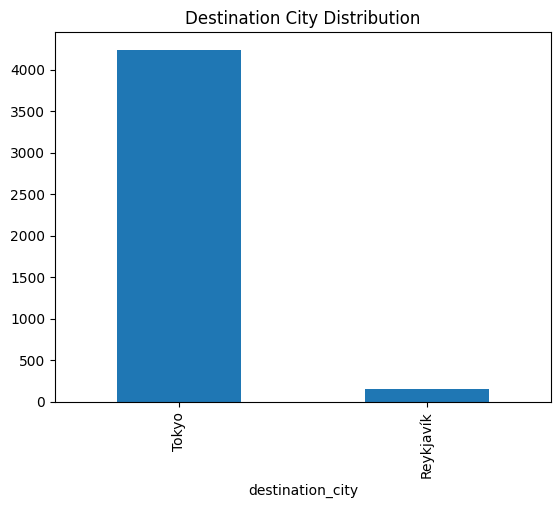

In [4]:
df["destination_city"].value_counts().plot(kind="bar")
plt.title("Destination City Distribution")

In [5]:
# Remove Reykjavík as it has very few samples and is a different market
df = df.drop(df[df["destination_city"] == "Reykjavík"].index)
df["destination_city"].value_counts()

destination_city
Tokyo    4238
Name: count, dtype: int64

Text(0.5, 1.0, 'Departure Date Distribution')

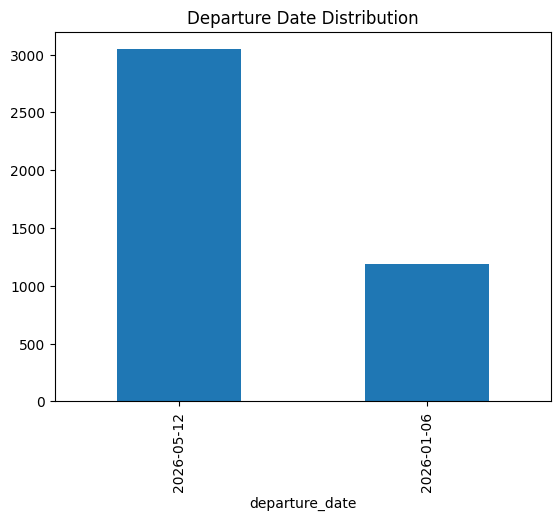

In [6]:
df["departure_date"].value_counts().plot(kind="bar")
plt.title("Departure Date Distribution")

In [7]:
# Split the dateset into two subsets for the two departure dates (January 6 and May 12)
january_df = df[df["departure_date"] == "2026-01-06"]
print(january_df["departure_date"].value_counts())

may_df = df[df["departure_date"] == "2026-05-12"]
print(may_df["departure_date"].value_counts())

departure_date
2026-01-06    1193
Name: count, dtype: int64
departure_date
2026-05-12    3045
Name: count, dtype: int64


In [8]:
print("January duplicate observations:", january_df.duplicated().sum())
print("May duplicate observations:", may_df.duplicated().sum())

January duplicate observations: 299
May duplicate observations: 804


In [9]:
# Drop duplicate observations
january_df = january_df.drop_duplicates()
may_df = may_df.drop_duplicates()

In [10]:
print(january_df["departure_date"].value_counts())
print(may_df["departure_date"].value_counts())

departure_date
2026-01-06    894
Name: count, dtype: int64
departure_date
2026-05-12    2241
Name: count, dtype: int64


In [11]:
print("May minimum timestamp:", may_df["timestamp_searched"].min())
print("May maximum timestamp:", may_df["timestamp_searched"].max())
print("May unique timestamps:", may_df["timestamp_searched"].nunique())

print("January minimum timestamp:", january_df["timestamp_searched"].min())
print("January maximum timestamp:", january_df["timestamp_searched"].max()) 
print("January unique timestamps:", january_df["timestamp_searched"].nunique())

May minimum timestamp: 2025/10/12
May maximum timestamp: 2026/05/11
May unique timestamps: 200
January minimum timestamp: 2025/07/15
January maximum timestamp: 2025/10/01
January unique timestamps: 64


From here on, going to only focus on the May departure date `may_df` dataframe.

In [12]:
# Convert timestamps to datetime and calculate days until departure to store in a new column
may_df["timestamp_searched"] = pd.to_datetime(may_df["timestamp_searched"], format="%Y/%m/%d")
may_df["departure_date"] = pd.to_datetime(may_df["departure_date"], format="%Y-%m-%d")
may_df["days_until_departure"] = (may_df["departure_date"] - may_df["timestamp_searched"]).dt.days

print(may_df["days_until_departure"].describe())

count    2241.000000
mean      115.119589
std        59.325547
min         1.000000
25%        66.000000
50%       114.000000
75%       169.000000
max       212.000000
Name: days_until_departure, dtype: float64


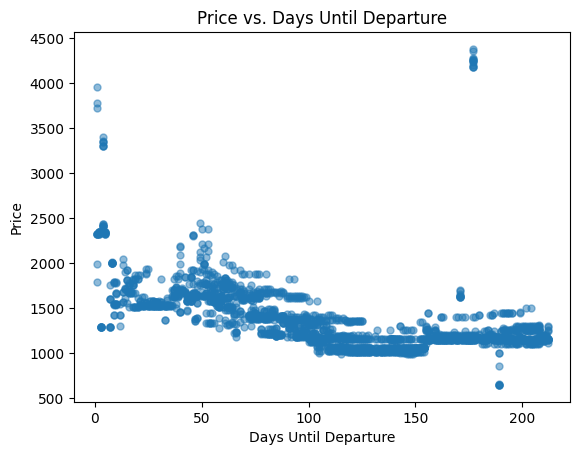

In [13]:
# Visualize price vs. days until departure to see the relationship between the two variables and identify any trends or patterns
plt.plot(may_df["days_until_departure"], may_df["total_cost"], marker="o", linestyle="", markersize=5, alpha=0.5)
plt.title("Price vs. Days Until Departure")
plt.xlabel("Days Until Departure")
plt.ylabel("Price") 
plt.show()

In [14]:
# Change the single "late night" category to "night" to reduce the number of categories and simplify the model
display(may_df["departure_time"].value_counts())

may_df.loc[may_df["departure_time"] == "late night", "departure_time"] = "night"

display(may_df["departure_time"].value_counts())

# Extract the month from the timestamp to create a new feature for seasonality
may_df["month_searched"] = may_df["timestamp_searched"].dt.month
display(may_df["month_searched"].value_counts())

departure_time
early morning    1088
morning           661
evening           201
night             189
afternoon         100
late night          2
Name: count, dtype: int64

departure_time
early morning    1088
morning           661
evening           201
night             191
afternoon         100
Name: count, dtype: int64

month_searched
11    367
1     347
3     343
2     340
12    309
10    257
4     194
5      84
Name: count, dtype: int64

In [15]:
# Create a unique flight identifier by combining the airline and flight number to capture any flight-specific patterns in the data
may_df["flight_id"] = (
    may_df["airline"].astype(str) + "_" + may_df["flight_code"].astype(str)
)

display(may_df["flight_id"].nunique())
display(may_df["flight_id"].value_counts())

66

flight_id
United Airlines_7937      235
All Nippon Airways_113    213
United Airlines_487       200
United Airlines_2431      183
American Airlines_6283    112
                         ... 
United Airlines_1627        1
United Airlines_469         1
American Airlines_3485      1
American Airlines_4720      1
American Airlines_4113      1
Name: count, Length: 66, dtype: int64

In [16]:
# Create multiple versions of the dataset with different thresholds to compare model performance and class balance across different definitions of "good price"
label_thresholds = [0.035, 0.04, 0.05, 0.06, 0.10]
processed_dfs = {}

for threshold in label_thresholds:
    print(f"Threshold df: {threshold}")
    processed_dfs[threshold] = create_target_variable(may_df, future_window=14, threshold=threshold)

Threshold df: 0.035
target
0    1095
1    1080
Name: count, dtype: int64
target
0    0.503448
1    0.496552
Name: proportion, dtype: float64
Threshold df: 0.04
target
1    1203
0     972
Name: count, dtype: int64
target
1    0.553103
0    0.446897
Name: proportion, dtype: float64
Threshold df: 0.05
target
1    1388
0     787
Name: count, dtype: int64
target
1    0.638161
0    0.361839
Name: proportion, dtype: float64
Threshold df: 0.06
target
1    1417
0     758
Name: count, dtype: int64
target
1    0.651494
0    0.348506
Name: proportion, dtype: float64
Threshold df: 0.1
target
1    1633
0     542
Name: count, dtype: int64
target
1    0.750805
0    0.249195
Name: proportion, dtype: float64


In [17]:
# Feature selection
predictors = [
    "airline",
    "departure_time",
    "stops",
    "duration",
    "total_cost",
    "day_searched",
    "month_searched",
    "days_until_departure"
]

target = "target"

In [18]:
# Create splits for each processed dataframe with different thresholds
splits = {}

for name, df in processed_dfs.items():
    print(f"Creating splits for threshold: {name}")
    X_train, y_train, X_val, y_val, X_test, y_test , train_df, val_df, test_df= split_data_chronologically(df, predictors, target)
    splits[name] = {"X_train": X_train,
                    "y_train": y_train,
                    "X_val": X_val,
                    "y_val": y_val,
                    "X_test": X_test,
                    "y_test": y_test,
                    "train_df": train_df,
                    "val_df": val_df,
                    "test_df": test_df
    }
    # inspect_splits(X_train.join(y_train), X_val.join(y_val), X_test.join(y_test), y_train, y_val, y_test)

Creating splits for threshold: 0.035
Creating splits for threshold: 0.04
Creating splits for threshold: 0.05
Creating splits for threshold: 0.06
Creating splits for threshold: 0.1


In [19]:
# Check the splits for the 0.05 threshold version of the dataset to verify that the date ranges and class
# balance look reasonable before proceeding with model training and evaluation
split = splits[0.05]

print("Train:", split["train_df"]["timestamp_searched"].min(), "to", split["train_df"]["timestamp_searched"].max())
print("Validation:", split["val_df"]["timestamp_searched"].min(), "to", split["val_df"]["timestamp_searched"].max())
print("Test:", split["test_df"]["timestamp_searched"].min(), "to", split["test_df"]["timestamp_searched"].max())

Train: 2025-10-12 00:00:00 to 2026-02-07 00:00:00
Validation: 2026-02-22 00:00:00 to 2026-03-08 00:00:00
Test: 2026-03-23 00:00:00 to 2026-05-11 00:00:00


In [20]:
# Categorical predictors
categorical_features = [
    "airline",
    "departure_time",
    "stops",
    "day_searched",
    "month_searched"
]

# Numerical predictors
numerical_features = [
    "duration",
    "total_cost",
    "days_until_departure"
]

In [21]:
# Preprocess the data for each split and store the processed datasets in a new dictionary
processed_data = {}
preprocessors = {}

for name, split in splits.items():
    print(f"Preprocessing data for threshold: {name}")
    X_train_processed, X_val_processed, X_test_processed, fitted_preprocessor = preprocess_data(
        split["X_train"],
        split["X_val"],
        split["X_test"],
        numerical_features,
        categorical_features
    )
    processed_data[name] = {
        "X_train_processed": X_train_processed,
        "X_val_processed": X_val_processed,
        "X_test_processed": X_test_processed
    }
    
    preprocessors[name] = fitted_preprocessor

Preprocessing data for threshold: 0.035
Preprocessing data for threshold: 0.04
Preprocessing data for threshold: 0.05
Preprocessing data for threshold: 0.06
Preprocessing data for threshold: 0.1


### Logistic Regression Model

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train a logistic regression model
def train_logistic_regression(X_train_processed, y_train):
    log_model = LogisticRegression(max_iter=1000, random_state=42)
    log_model.fit(X_train_processed, y_train)
    
    return log_model

In [23]:
# Train logistic regression models for each processed dataset with different thresholds and store the models in a new dictionary
log_models = {}

for name, df in processed_dfs.items():
    print(f"Fitting model for threshold: {name}")
    split = splits[name]
    processed = processed_data[name]

    log_models[name] = train_logistic_regression(processed["X_train_processed"], split["y_train"])
   

Fitting model for threshold: 0.035
Fitting model for threshold: 0.04
Fitting model for threshold: 0.05
Fitting model for threshold: 0.06
Fitting model for threshold: 0.1


In [24]:
# Predict and evaluate the models for each processed dataset with different thresholds and store the results in a new dictionary
evaluation_results = {}

for name, model in log_models.items():
    print(f"Evaluating model for threshold: {name}")
    processed = processed_data[name]
    evaluation_results[name] = evaluate_model(model, processed["X_train_processed"], processed["X_val_processed"])

Evaluating model for threshold: 0.035
Evaluating model for threshold: 0.04
Evaluating model for threshold: 0.05
Evaluating model for threshold: 0.06
Evaluating model for threshold: 0.1


In [25]:
# Print evaluation metrics for each model with different thresholds
for name, results in evaluation_results.items():
    print(f"\nEvaluation Metrics for Model: {name}")
    split = splits[name]
    print_evaluation_metrics(split["y_train"], split["y_val"], results[0], results[1], results[3])


Evaluation Metrics for Model: 0.035
Training Accuracy: 0.6869501466275659
Validation Accuracy: 0.6026490066225165

Validation Confusion Matrix:
[[71 15]
 [45 20]]

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.83      0.70        86
           1       0.57      0.31      0.40        65

    accuracy                           0.60       151
   macro avg       0.59      0.57      0.55       151
weighted avg       0.59      0.60      0.57       151

Validation ROC AUC Score:
0.7660107334525939

Evaluation Metrics for Model: 0.04
Training Accuracy: 0.7426686217008798
Validation Accuracy: 0.7086092715231788

Validation Confusion Matrix:
[[67 16]
 [28 40]]

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.81      0.75        83
           1       0.71      0.59      0.65        68

    accuracy                           0.71       151
   macro avg 

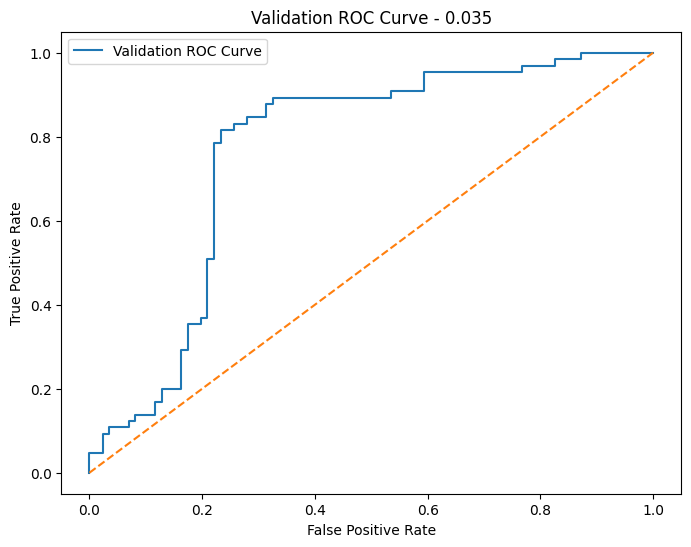

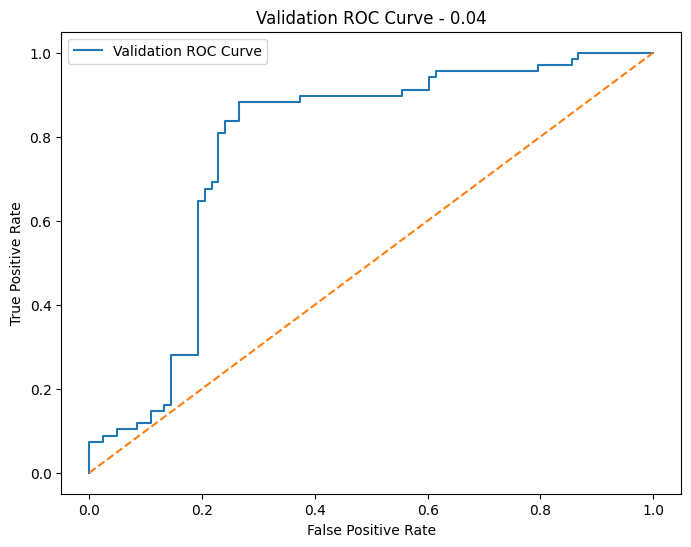

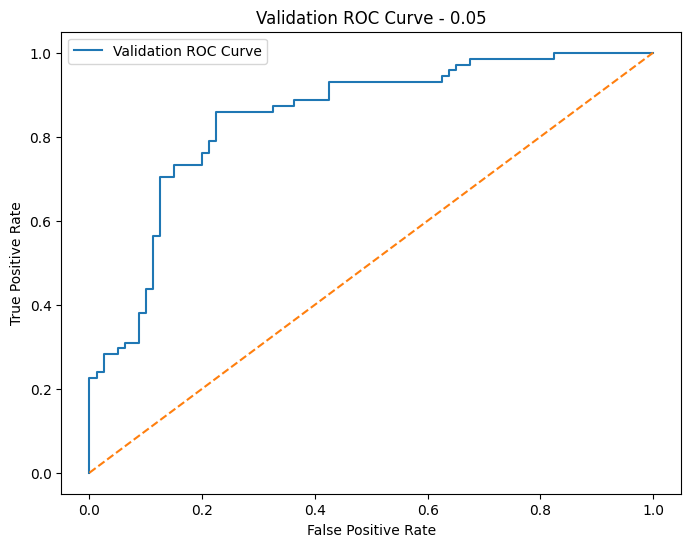

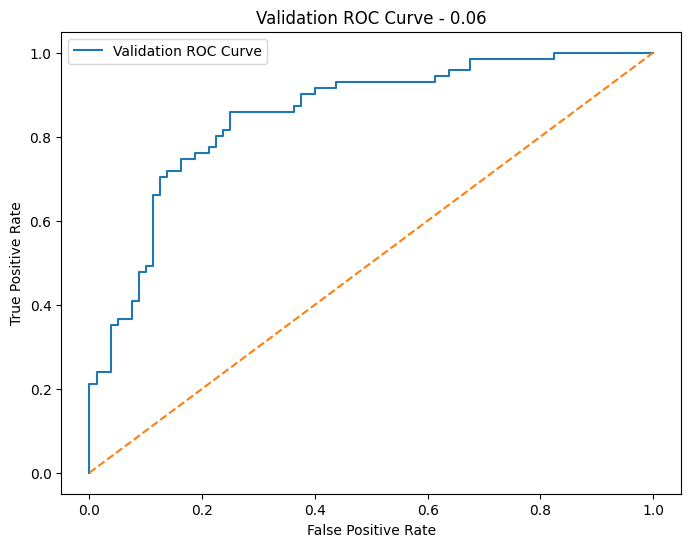

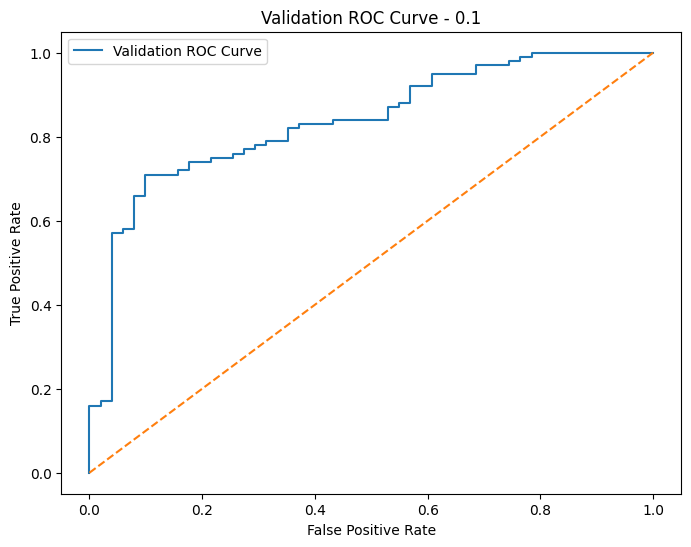

In [26]:
for name, results in evaluation_results.items():
    split = splits[name]
    plot_roc_curve(split["y_val"], results[3], name)

In [27]:
# Lock in the best threshold based on the evaluation metrics
# Inspect the feature importance of the corresponding logistic regression model to understand which features are most influential 
# in predicting whether to buy now or wait for a better price in the future
best_threshold = 0.05
best_log_model = log_models[best_threshold]
fitted_preprocessor = preprocessors[best_threshold]

# Get encoded categorical feature names
encoded_feature_names = (
    fitted_preprocessor.named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

# Combine feature names
feature_names = (
    numerical_features
    + list(encoded_feature_names)
)

# Extract coefficients
coefficients = best_log_model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Absolute importance
coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()

# Odds ratios
coef_df["OddsRatio"] = np.exp(coef_df["Coefficient"])

# Sort by importance
coef_df = coef_df.sort_values(
    by="AbsCoefficient",
    ascending=False
)

print(coef_df.head(20))

                         Feature  Coefficient  AbsCoefficient  OddsRatio
1                     total_cost    -7.007768        7.007768   0.000905
26             month_searched_12    -1.841160        1.841160   0.158633
24             month_searched_10     1.746071        1.746071   5.732036
23              month_searched_2     1.507549        1.507549   4.515647
22              month_searched_1    -1.453646        1.453646   0.233717
2           days_until_departure    -1.328058        1.328058   0.264991
9         departure_time_evening     1.064904        1.064904   2.900562
5      airline_American Airlines    -1.014619        1.014619   0.362541
4     airline_All Nippon Airways     0.674639        0.674639   1.963324
11          departure_time_night    -0.656986        0.656986   0.518411
13                       stops_1    -0.560935        0.560935   0.570675
12                       stops_0     0.549187        0.549187   1.731844
8   departure_time_early morning    -0.445587      

### Random Forest Model

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200,
                            max_depth=15,
                            min_samples_leaf=10,
                            random_state=42)
print(f"Fitting Random Forest model for threshold: {best_threshold}")
model_rf = rf.fit(processed_data[best_threshold]["X_train_processed"], splits[best_threshold]["y_train"])

Fitting Random Forest model for threshold: 0.05


In [29]:
print(f"Evaluating Random Forest model for threshold: {best_threshold}")
rf_evaluation_results = evaluate_model(model_rf, processed_data[best_threshold]["X_train_processed"], processed_data[best_threshold]["X_val_processed"])

Evaluating Random Forest model for threshold: 0.05


In [30]:
print("\nEvaluation Metrics for Random Forest Model:")
print_evaluation_metrics(splits[best_threshold]["y_train"],
                         splits[best_threshold]["y_val"],
                         rf_evaluation_results[0],
                         rf_evaluation_results[1],
                         rf_evaluation_results[3]
)


Evaluation Metrics for Random Forest Model:
Training Accuracy: 0.8988269794721407
Validation Accuracy: 0.6754966887417219

Validation Confusion Matrix:
[[44 36]
 [13 58]]

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.55      0.64        80
           1       0.62      0.82      0.70        71

    accuracy                           0.68       151
   macro avg       0.69      0.68      0.67       151
weighted avg       0.70      0.68      0.67       151

Validation ROC AUC Score:
0.7722711267605634



ROC Curve for Random Forest Model:


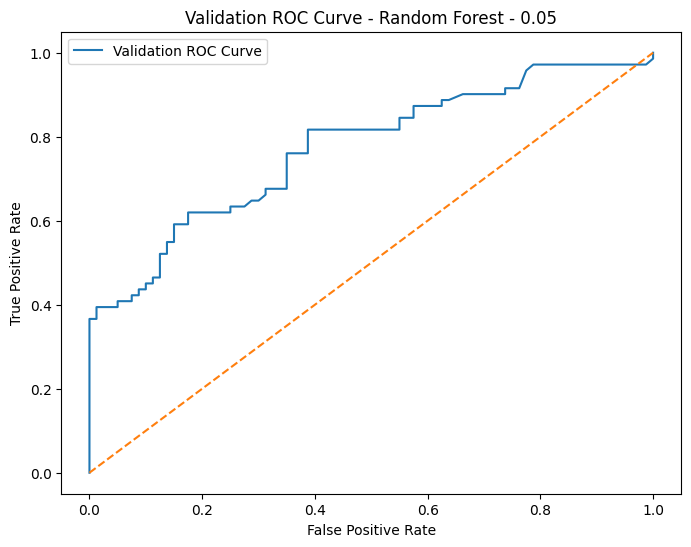

In [31]:
print("\nROC Curve for Random Forest Model:")
plot_roc_curve(splits[best_threshold]["y_val"],
               rf_evaluation_results[3],
               f"Random Forest - {best_threshold}"
)

### XGBoost Model

In [32]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.03,
    max_depth=2,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5.0,
    reg_alpha=0.5,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

print(f"Fitting XGBoost model for threshold: {best_threshold}")
xgb_model.fit(
    processed_data[best_threshold]["X_train_processed"],
    splits[best_threshold]["y_train"]
)

Fitting XGBoost model for threshold: 0.05


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [33]:
print(f"Evaluating XGBoost model for threshold: {best_threshold}")
xgb_evaluation_results = evaluate_model(xgb_model, processed_data[best_threshold]["X_train_processed"], processed_data[best_threshold]["X_val_processed"])

Evaluating XGBoost model for threshold: 0.05


In [34]:
print("\nEvaluation Metrics for XGBoost Model:")
print_evaluation_metrics(splits[best_threshold]["y_train"],
                         splits[best_threshold]["y_val"],
                         xgb_evaluation_results[0],
                         xgb_evaluation_results[1],
                         xgb_evaluation_results[3]
)


Evaluation Metrics for XGBoost Model:
Training Accuracy: 0.8291788856304986
Validation Accuracy: 0.7019867549668874

Validation Confusion Matrix:
[[67 13]
 [32 39]]

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.84      0.75        80
           1       0.75      0.55      0.63        71

    accuracy                           0.70       151
   macro avg       0.71      0.69      0.69       151
weighted avg       0.71      0.70      0.69       151

Validation ROC AUC Score:
0.7700704225352113


### Logistic Regression Model - Tuning

Since Logistic regression performed best out of all 3 models using a `0.05` threshold. Now I'll fine tune that logistic regression model
to different probability thresholds to find the optimal model for predicting with the test split.

In [35]:
X_val_processed = processed_data[best_threshold]["X_val_processed"]
y_val = splits[best_threshold]["y_val"]

y_val_prob = best_log_model.predict_proba(X_val_processed)[:, 1]

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

probability_thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70
]

results = []

for threshold in probability_thresholds:
    # Convert probabilities into class predictions
    y_val_pred = (y_val_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)

    results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

In [37]:
threshold_results_df = pd.DataFrame(results)

print(threshold_results_df)

   threshold  accuracy  precision    recall        f1
0       0.30  0.781457   0.806452  0.704225  0.751880
1       0.35  0.781457   0.806452  0.704225  0.751880
2       0.40  0.788079   0.819672  0.704225  0.757576
3       0.45  0.781457   0.827586  0.676056  0.744186
4       0.50  0.748344   0.811321  0.605634  0.693548
5       0.55  0.701987   0.795455  0.492958  0.608696
6       0.60  0.688742   0.785714  0.464789  0.584071
7       0.65  0.682119   0.794872  0.436620  0.563636
8       0.70  0.668874   0.783784  0.408451  0.537037


In [38]:
threshold_results_df.sort_values(
    by="f1",
    ascending=False
)

,threshold,accuracy,precision,recall,f1
2,0.40,0.788079,0.819672,0.704225,0.757576
0,0.30,0.781457,0.806452,0.704225,0.751880
1,0.35,0.781457,0.806452,0.704225,0.751880
3,0.45,0.781457,0.827586,0.676056,0.744186
4,0.50,0.748344,0.811321,0.605634,0.693548
5,0.55,0.701987,0.795455,0.492958,0.608696
6,0.60,0.688742,0.785714,0.464789,0.584071
7,0.65,0.682119,0.794872,0.436620,0.563636
8,0.70,0.668874,0.783784,0.408451,0.537037


In [ ]:
# Compare the performance of the Logistic Regression (0.40 threshold) model to the Random Forest and XGBoost models using the same 
# threshold for converting probabilities into class predictions (0.05). One last check to confirm that the logistic regression model
# with the 0.40 threshold is still the best performing model based on the evaluation metrics before proceeding to test set evaluation
# and final model selection.

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

best_threshold = 0.05
log_prob_threshold = 0.40

X_val_processed = processed_data[best_threshold]["X_val_processed"]
y_val = splits[best_threshold]["y_val"]

model_results = []

models = {
    "Logistic Regression": log_models[best_threshold],
    "Random Forest": model_rf,
    "XGBoost": xgb_model
}

for model_name, model in models.items():
    y_val_prob = model.predict_proba(X_val_processed)[:, 1]
    
    if model_name == "Logistic Regression":
        y_val_pred = (y_val_prob >= log_prob_threshold).astype(int)
    else:
        y_val_pred = model.predict(X_val_processed)

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1": f1_score(y_val, y_val_pred),
        "ROC-AUC": roc_auc_score(y_val, y_val_prob)
    })

model_results_df = pd.DataFrame(model_results)

display(model_results_df)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.788079,0.819672,0.704225,0.757576,0.846127
1,Random Forest,0.675497,0.617021,0.816901,0.703030,0.772271
2,XGBoost,0.701987,0.750000,0.549296,0.634146,0.770070


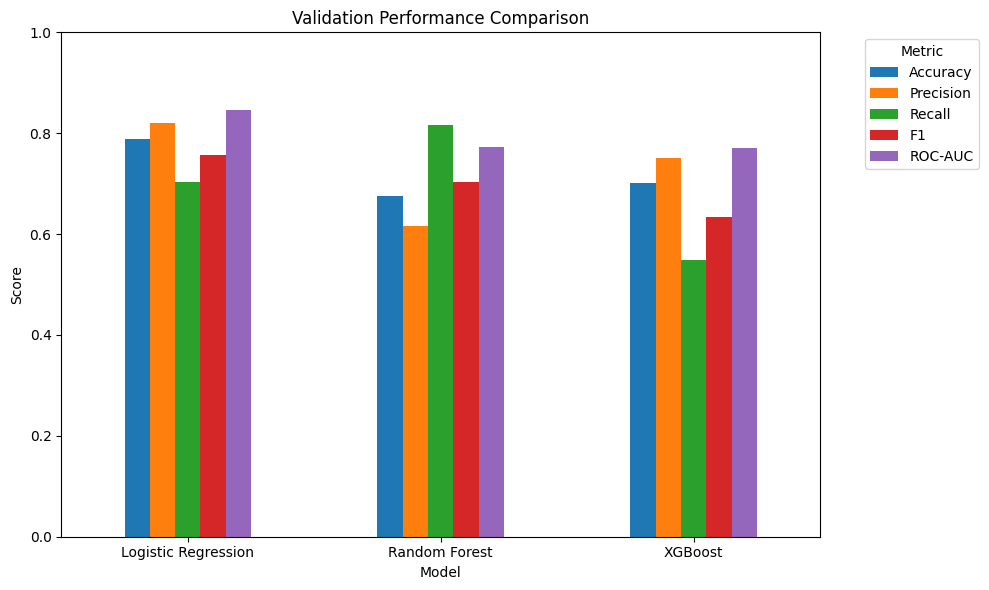

In [44]:
plot_df = model_results_df.set_index("Model")

ax = plot_df.plot(kind="bar", figsize=(10, 6))

plt.title("Validation Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

With a probability threshold of `0.4`, the final configuration will be:
    Model: Logistic Regression
    Label threshold: 0.05
    Future window: 14
    Probability threshold: 0.40

In [39]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Final configuration
best_threshold = 0.05
probability_threshold = 0.40

# Retrieve final logistic model and test data
final_log_model = log_models[best_threshold]

X_test_processed = processed_data[best_threshold]["X_test_processed"]
y_test = splits[best_threshold]["y_test"]

# Get predicted probabilities and convert to class predictions
y_test_prob = final_log_model.predict_proba(X_test_processed)[:, 1]

# Apply tuned probability threshold to get final class predictions
y_test_pred = (y_test_prob >= probability_threshold).astype(int)

# Final test evaluation
print("Final Logistic Regression Test Results")
print(f"Label Threshold: {best_threshold}")
print(f"Probability Threshold: {probability_threshold}")

print("\nTest Accuracy:")
print(accuracy_score(y_test, y_test_pred))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

print("\nTest ROC-AUC:")
print(roc_auc_score(y_test, y_test_prob))

Final Logistic Regression Test Results
Label Threshold: 0.05
Probability Threshold: 0.4

Test Accuracy:
0.513595166163142

Test Confusion Matrix:
[[151   4]
 [157  19]]

Test Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.97      0.65       155
           1       0.83      0.11      0.19       176

    accuracy                           0.51       331
   macro avg       0.66      0.54      0.42       331
weighted avg       0.67      0.51      0.41       331


Test ROC-AUC:
0.6836876832844575


target
1    0.531722
0    0.468278
Name: proportion, dtype: float64


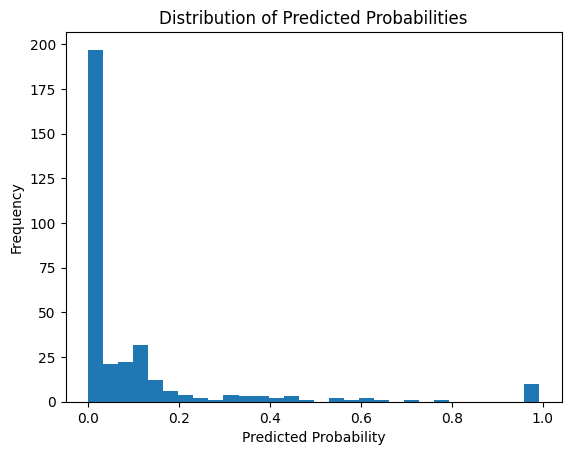

In [41]:
print(y_test.value_counts(normalize=True))

plt.hist(y_test_prob, bins=30)
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Probabilities')
plt.show()

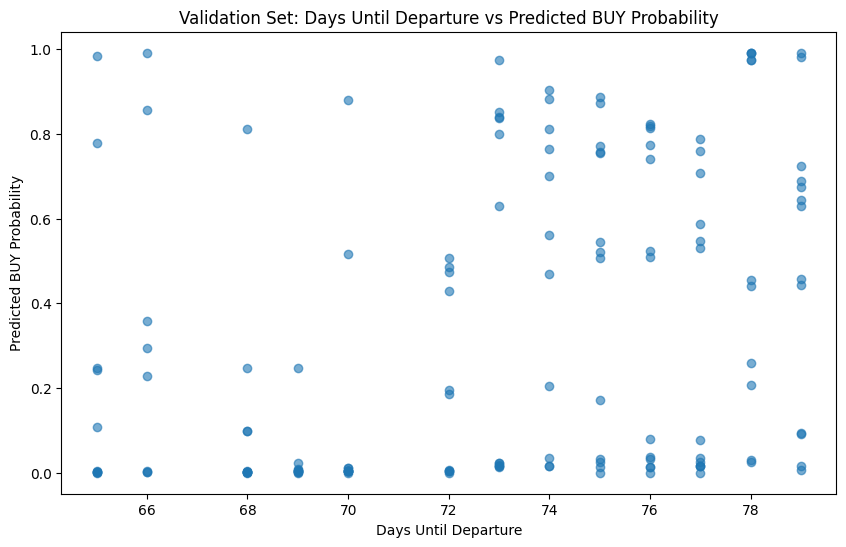

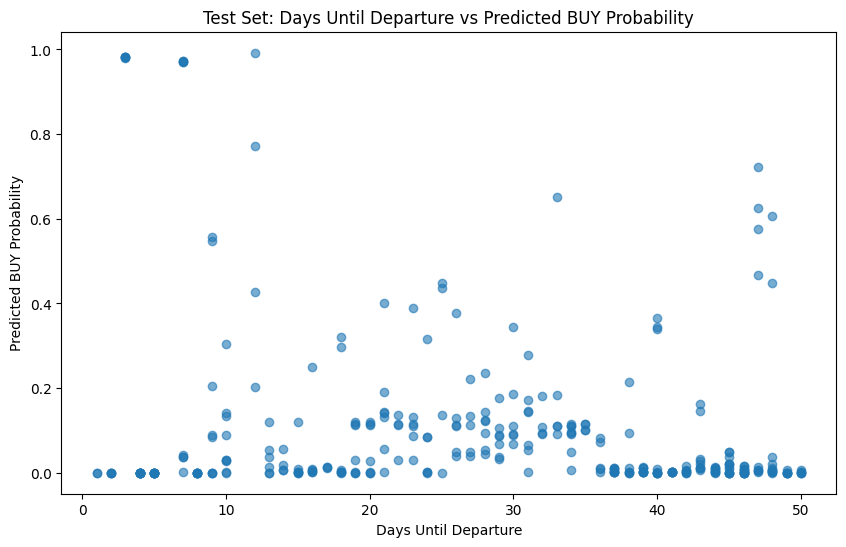

In [42]:
# Retrieve validation/test data
val_df = splits[best_threshold]["val_df"].copy()
test_df = splits[best_threshold]["test_df"].copy()

# Retrieve processed matrices
X_val_processed = processed_data[best_threshold]["X_val_processed"]
X_test_processed = processed_data[best_threshold]["X_test_processed"]

# Final logistic model
log_model = log_models[best_threshold]

# Predicted probabilities
val_df["predicted_probability"] = (
    log_model.predict_proba(X_val_processed)[:, 1]
)

test_df["predicted_probability"] = (
    log_model.predict_proba(X_test_processed)[:, 1]
)

# Validation plot
plt.figure(figsize=(10, 6))

plt.scatter(
    val_df["days_until_departure"],
    val_df["predicted_probability"],
    alpha=0.6
)

plt.title("Validation Set: Days Until Departure vs Predicted BUY Probability")
plt.xlabel("Days Until Departure")
plt.ylabel("Predicted BUY Probability")

plt.show()


# Test plot
plt.figure(figsize=(10, 6))

plt.scatter(
    test_df["days_until_departure"],
    test_df["predicted_probability"],
    alpha=0.6
)

plt.title("Test Set: Days Until Departure vs Predicted BUY Probability")
plt.xlabel("Days Until Departure")
plt.ylabel("Predicted BUY Probability")

plt.show()

### Conclusion

This project demonstrated that machine learning models can identify meaningful patterns within airfare pricing data and provide useful insights into flight booking behavior. Through feature engineering and temporal modeling techniques, the models were able to learn relationships between variables such as total cost, booking horizon, airline, departure timing, and historical price behavior to classify potential BUY and WAIT opportunities.

Among the evaluated models, Logistic Regression consistently provided the strongest overall performance on the validation data, outperforming more complex methods such as Random Forest and XGBoost. While tree-based models were able to capture nonlinear relationships, they also exhibited stronger tendencies toward overfitting and weaker temporal generalization. Logistic Regression produced the most balanced combination of accuracy, ROC-AUC, precision, and recall while remaining interpretable and computationally efficient.

One of the most important findings of the project was the impact of temporal distribution shift across booking horizons. The validation set primarily represented mid-range booking periods, while the final test set contained observations much closer to departure. As a result, the probability distributions learned during training did not generalize well to the later booking regime, causing a significant reduction in final test performance. This revealed that airfare pricing behavior changes substantially as departure approaches, creating a difficult forecasting environment where model calibration and decision thresholds may drift over time.

Although the final test performance was lower than the validation results, this outcome provided valuable insight into the challenges of real-world temporal machine learning systems. The project highlights the importance of careful chronological validation, leakage prevention, and understanding distribution shifts when building predictive models on sequential pricing data. Future improvements could include collecting additional data across multiple seasonal periods, building booking-horizon-specific models, incorporating external factors such as holidays or fuel prices, and exploring more advanced time-series or sequential modeling techniques.